<div style="border:solid Chocolate 2px; padding: 40px">
 
<b> Викентий, привет!👋</b> 

Меня зовут Кирилл Васильев, я буду ревьюером твоего проекта. Я предлагаю общаться на «ты», но если привычнее на «вы», просто скажи об этом! 

Я буду оставлять комментарии в твоем проекте. Пожалуйста, не удаляй их, они могут быть полезны в случае повторной проверки.

Свои комментарии я буду обозначать <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:
  
<br/> 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным. Здесь же я могу давать советы и предложения.
</div>
 
<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div> 
  

<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
 
  
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>  

 
<br/>
<div class="alert alert-info">
Рекомендую для твоих комментариев использовать синий или любой другой цветной фон. Я постараюсь ничего не пропустить, но если комментарии будут выделены, то это мне очень поможет!
</div>
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самостоятельно найти и исправить ее. На реальной работе твой руководитель будет поступать также. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку.



# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

## Введение

**Объект исследования** — поведение клиентов кофейной сети, зафиксированное в наборе данных `coffee_churn_dataset.csv`. **Предмет исследования** — зависимость факта оттока клиента от его характеристик и метрик использования продукта, а также качество модели, описывающей эту зависимость.

**Цель работы** — построить модель логистической регрессии для прогнозирования оттока клиентов на основе предоставленного набора данных и оценить её качество.

Для достижения цели поставлены следующие задачи:

1. Подготовить рабочую среду: установить и настроить необходимые библиотеки, зафиксировать значение `random_state`.
2. Загрузить данные из CSV-файла (`/datasets/coffee_churn_dataset.csv`), провести первичный осмотр набора данных.
3. Выполнить исследовательский анализ данных: изучить типы признаков, распределения значений, пропуски, дубликаты и дисбаланс целевого класса, оценить взаимосвязь признаков с целевой переменной.
4. Провести предобработку данных и сформировать обучающую и тестовую выборки с соблюдением корректного протокола разделения.
5. Обучить модель логистической регрессии и при необходимости настроить её гиперпараметры.
6. Оценить качество модели с помощью метрик классификации (F1-мера и Precision-Recall AUC (PR AUC)) и сравнить результат с базовым решением.
7. Проинтерпретировать полученные коэффициенты модели, определить наиболее значимые факторы оттока и сформулировать практические выводы.

**Выбор метода.** Логистическая регрессия выбрана как базовая и одновременно интерпретируемая модель бинарной классификации: она оценивает вероятность целевого события через логистическую функцию, устойчива к малым и средним по размеру наборам данных и позволяет напрямую интерпретировать влияние каждого признака через его коэффициент. Это делает модель удобной как для получения качественного прогноза, так и для содержательного объяснения причин оттока.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично по описанию. Цели и задачи ясны, обозначены корректно. Итак, решаем задачу бинарной классификации.
 


# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

### 1. Загрузка и импорт основных библиотек

In [ ]:
%pip install phik -q
%pip install numpy -q
%pip install pandas -q
%pip install seaborn -q
%pip install matplotlib -q
%pip install scipy -q
%pip install jinja2 -q
%pip install scikit-learn -q
%pip install category_encoders -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Для нас среда Практикума = среда заказика. Какие-то пакеты здесь уже предустановлены в версиях, которые не конфликтуют друг с другом. Тогда логично «не чинить то, что не ломалось», не инсталлировать принудительно то, что и так уже есть в среде. 

 
<br/>
<div class="alert alert-info">
А где можно посмотреть список предустановленных библиотек практикума, я бы тогда коментил эти библиотеки перед отправкой на проверку
</div>

In [ ]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import *
import phik
from sklearn.metrics import f1_score, average_precision_score, recall_score, precision_score, precision_recall_curve
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
import joblib

# Настройки вывода pandas: печатать все столбцы и строки без сокращения '...'
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

### 2. Фиксация константных значений

In [ ]:
RANDOM_STATE = 42
N_FOLDS = 5
SCORING_BASELINE = ['f1', 'average_precision', 'recall', 'precision']
SCORING_GRID_SEARCH = 'average_precision'

### 3. Выгрузка дата фрейма

In [ ]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

## Этап 2. Первичный анализ данных

Логистическая регрессия чувствительна к качеству входных данных: пропуски, выбросы, а также избыточные и сильно коррелирующие между собой признаки искажают оценки коэффициентов и снижают качество прогноза. Поэтому прежде чем обучать модель, необходимо разобраться, что именно описывает каждая запись набора `coffee_churn_dataset`, как устроена целевая переменная и каким преобразованиям должны подвергнуться данные, чтобы модель обучалась на корректной и информативной выборке.

Первичный анализ носит исследовательский характер: решения на этом этапе принимаются не окончательно, а как обоснованные гипотезы, которые далее будут реализованы в пайплайнах предобработки (этап 3). При этом каждый вывод должен опираться на расчёты и визуализации, а не на предположения.

В рамках этапа необходимо:

1. **Описать данные.** Кратко сообщить, что известно о пользователях и их поведении: какие процессы — покупки, активность в приложении, лояльность, вкусовые предпочтения — отражает каждый признак.

2. **Описать целевую переменную.** Обратить внимание на возможные особенности её распределения и проверить, наблюдается ли дисбаланс классов: от этого зависят выбор метрик качества и способ обучения модели.

3. **Описать признаки.** Определить, все ли из них важны, и аргументировать, какие признаки (если такие есть) можно удалить.

4. **Обработать пропущенные значения.** Объяснить, как пропуски влияют на данные, и выбрать стратегию их заполнения.

5. **Проанализировать категориальные признаки.** Выяснить, какие признаки нужно кодировать и почему; оценить, какие из них можно использовать для генерации новых признаков, и указать возможные стратегии; определить признаки, подлежащие удалению.

6. **Проанализировать выбросы.** Определить, как они влияют на данные, и выбрать способ их обработки.

7. **Посчитать корреляции между признаками.** Построить необходимые визуализации и определить, есть ли признаки, которые можно убрать на основании их корреляции с другими.

8. **Написать выводы** по результатам исследовательского анализа данных.

### 1. Описание данных

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [ ]:
df.head(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,whole,1.0,guatemala,medium,none,NaN,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,oat,1.0,guatemala,small,premium,17.895637,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,skim,0.0,brazil,medium,none,11.405533,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,almond,1.0,colombia,medium,none,15.948239,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,medium,whole,0.0,kenya,large,none,5.064097,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,dark,soy,1.0,NaN,medium,none,11.658836,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,light,almond,1.0,brazil,small,basic,14.785010,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,medium,skim,1.0,guatemala,medium,NaN,7.129673,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,light,whole,NaN,guatemala,medium,NaN,6.706418,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


In [ ]:
df.describe(include='all')

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
count,10450,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,10192,10334,9782,9461.000000,9768,9946,9512,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9771,9719.000000,10114,9840.000000,10340,10450.000000
unique,10450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,6,NaN,6,3,4,NaN,NaN,NaN,NaN,NaN,4,NaN,3,NaN,100,NaN
top,user_00318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,arabica,medium,whole,NaN,ethiopia,medium,none,NaN,NaN,NaN,NaN,NaN,spring,NaN,android,NaN,geo_2,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6134,3458,2876,NaN,1690,4925,3803,NaN,NaN,NaN,NaN,NaN,2507,NaN,4611,NaN,1629,NaN
mean,NaN,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,NaN,NaN,NaN,0.701194,NaN,NaN,NaN,11.330895,0.753052,4.206709,4.022460,1.013362,NaN,14.554584,NaN,0.192480,NaN,0.060191
std,NaN,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,NaN,NaN,NaN,0.457759,NaN,NaN,NaN,14.528887,0.431258,0.782212,1.207883,1.010342,NaN,15.308869,NaN,0.394268,NaN,0.237852
min,NaN,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,1.415526,-0.897000,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
25%,NaN,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,6.313628,1.000000,3.675543,3.214157,0.000000,NaN,4.000000,NaN,0.000000,NaN,0.000000
50%,NaN,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,9.228383,1.000000,4.203555,3.990032,1.000000,NaN,10.000000,NaN,0.000000,NaN,0.000000
75%,NaN,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,12.726649,1.000000,4.717292,4.845225,2.000000,NaN,20.000000,NaN,0.000000,NaN,0.000000


**Общая характеристика данных**
Датасет coffee_churn содержит 10 450 строк и 27 столбцов: user_id, 25 признаков и бинарную целевую переменную churn.

### 2. Целевая переменная

In [ ]:
churn_counts = df['churn'].value_counts()

In [ ]:
churn_norm = round(df['churn'].value_counts(normalize=True) * 100, 2)

In [ ]:
f'Churn — бинарный признак, но дисбаланс классов очень сильный: {churn_counts[1]} ушедших ({churn_norm[1]}%) против {churn_counts[0]} оставшегося ({churn_norm[0]}%)'

'Churn — бинарный признак, но дисбаланс классов очень сильный: 629 ушедших (6.02%) против 9821 оставшегося (93.98%)'

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 


 Дисбаланс есть и он существенный, впрочем это ожидаемо для задачи оттока




### 3. Разбор имеющихся признаков

**Структура датасета:** 27 столбцов = 1 идентификатор + 13 числовых признаков + 12 категориальных + 1 целевая переменная.

#### Числовые признаки (13)

1. `days_since_last_order` — 39 уникальных значений, диапазон 0…40.
2. `order_frequency_month` — 9 419 уникальных значений, диапазон 0.011…27.389.
3. `order_frequency_week` — 9 625 уникальных значений, диапазон −0.169…6.303; **есть отрицательные значения**.
4. `avg_order_value` — 9 441 уникальное значение, диапазон −32.08…5 901.97; **есть отрицательные значения**.
5. `median_order_value` — 9 201 уникальное значение, диапазон −10.35…2 189.10; **есть отрицательные значения**.
6. `total_spent_last_month` — 9 713 уникальных значений, диапазон −43.72…79 298.85 **есть отрицательные значения**.
7. `total_spent_last_week` — 9 090 уникальных значений, диапазон −2 290.56…8 615.99 **есть отрицательные значения**.
8. `discount_usage_rate` — 9 618 уникальных значений, диапазон 0.0022…0.8873.
9. `app_opens_per_week` — 9 065 уникальных значений, диапазон 0…224.59.
10. `review_rating_last_10` — 9 328 уникальных значений, диапазон 1.4155…7.3844.
11. `review_rating_last_1` — 9 182 уникальных значения, диапазон −0.8970…8.5584 **есть отрицательные значения**.
12. `app_crashes_last_month` — 8 уникальных значений, диапазон 0…7.
13. `days_since_last_promo` — 106 уникальных значений, диапазон 0…140.

#### Категориальные признаки (12)

1. `last_coffee_type` — 3 уровня (arabica, robusta, blend), самый частый arabica — 60.2 %.
2. `preferred_roast` — 3 уровня (light, medium, dark), самый частый medium — 33.5 %.
3. `milk_preference` — 6 уровней (whole, oat, almond, skim, none, soy), самый частый whole — 29.4 %.
4. `coffee_bean_origin` — 6 уровней (ethiopia, kenya, vietnam, guatemala, brazil, colombia), самый частый ethiopia — 17.3 %.
5. `last_drink_size` — 3 уровня (small, medium, large), самый частый medium — 49.5 %.
6. `subscription_status` — 4 уровня (none, basic, premium, pro), самый частый none — 40.0 %.
7. `seasons` — 4 уровня (spring, autumn, winter, summer), самый частый spring — 25.7 %.
8. `phone_type` — 3 уровня (android, ios, web), самый частый android — 45.6 %.
9. `geo_location` — 100 уровней (geo_1 … geo_100), самый частый geo_2 — 15.8 %.
10. `seasonal_menu_tried` — значения 0/1, доля единиц 70.1 %.
11. `notifications_enabled` — значения 0/1, доля единиц 75.3 %.
12. `coffee_preference_change` — значения 0/1, доля единиц 19.3 %.

#### Идентификатор

- `user_id` — 10 450 уникальных значений, то есть ровно по одному на строку; признаком не является, на этапе предобработки удаляется.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Для финального оформления проекта лучше то, что можем вывести в таблицах или на графиках не переписывать механически текстом, так как текст будет сложнее считывать. В текстовых комментариях лучше выделять главное, привлекать внимание к важному, объяснять, аргументировать дальнейшие действия.

In [ ]:
#Создадим переменную для учета лишних признаков, чтоб удалить их во время обработки
columns_to_drop = []
columns_to_drop.append('user_id')

In [ ]:
# Выделим категориальные признаки в отдельную переменную
cats = ['last_coffee_type', 'preferred_roast', 'milk_preference'
       , 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size'
       , 'subscription_status', 'notifications_enabled', 'seasons'
       , 'phone_type', 'coffee_preference_change']

In [ ]:
# Выделим числовые признаки в отдельную переменную с помощью list comprehension (идентификатор, целевую переменную и geo_location тоже уберем)
nums = [x for x in df.columns if x not in cats + ['user_id', 'churn', 'geo_location']]


### 4. Изучение пропусков
Выведем информацию по пропущенным данным в датасете и визуализируем результаты.

In [ ]:
round(df.isna().mean().sort_values(ascending=False), 3)

seasonal_menu_tried         0.095
days_since_last_order       0.090
total_spent_last_week       0.090
subscription_status         0.090
app_opens_per_week          0.086
review_rating_last_1        0.082
median_order_value          0.080
days_since_last_promo       0.070
app_crashes_last_month      0.069
review_rating_last_10       0.066
coffee_bean_origin          0.065
seasons                     0.065
milk_preference             0.064
coffee_preference_change    0.058
order_frequency_month       0.057
avg_order_value             0.056
notifications_enabled       0.051
last_drink_size             0.048
discount_usage_rate         0.038
order_frequency_week        0.037
phone_type                  0.032
total_spent_last_month      0.028
last_coffee_type            0.025
preferred_roast             0.011
geo_location                0.011
user_id                     0.000
churn                       0.000
dtype: float64

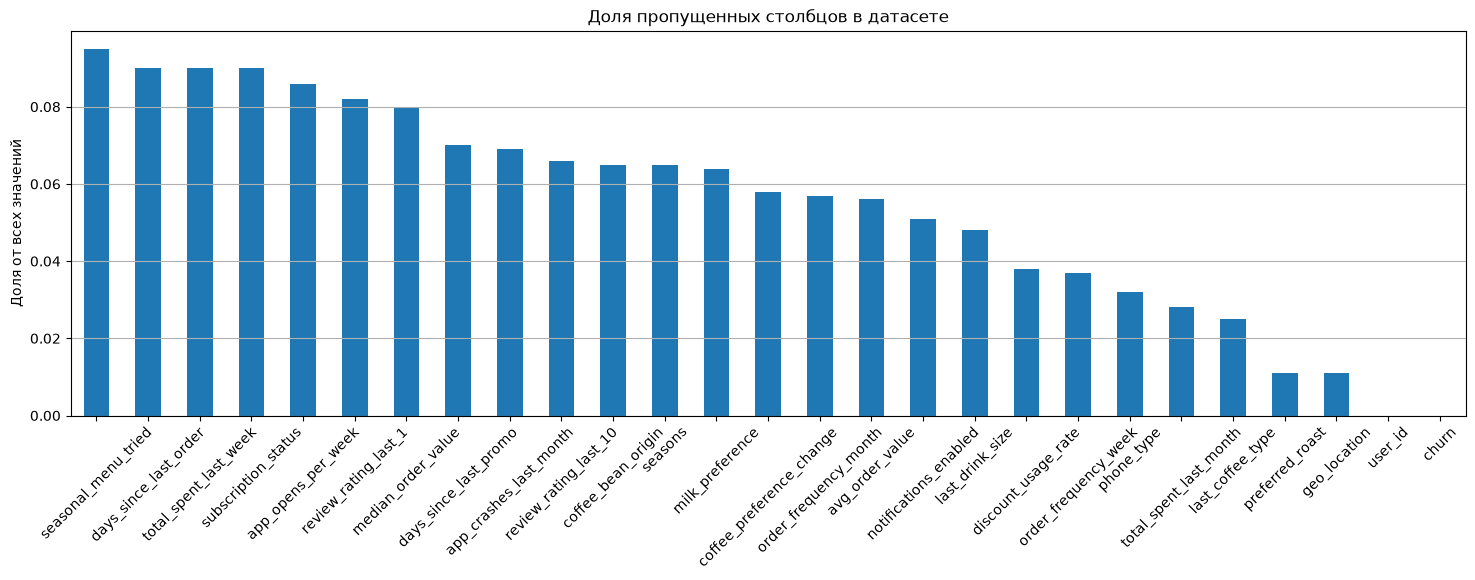

In [ ]:
round(df.isna().mean().sort_values(ascending=False), 3).plot(
    kind='bar'
    ,rot=45
    ,figsize=(18, 5)
    ,title='Доля пропущенных столбцов в датасете'
    ,ylabel='Доля от всех значений'
)
plt.grid(axis='y')
plt.show()


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Также полезно подсчитать, какая доля строк имеет хотя бы один пропуск

```
# Сколько строк имеют хотя бы один пропуск
rows_with_nan = df.isna().any(axis=1).sum()
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_nan} из {len(df)} "
      f"({rows_with_nan/len(df)*100:.2f}%)")

```




Посмотрим есть ли зависимость между столбцами с пропусками и связанными с ними столбцами, чтоб попытаться найти причину пропусков

In [ ]:
#Зависимость пропусков в столбце total_spent_last_week и пропусков в столбце order_frequency_week
df[df['total_spent_last_week'].isna()]['order_frequency_week'].value_counts(dropna=False, sort=True)[:5]


order_frequency_week
NaN         41
0.343946     3
0.801858     2
0.808305     2
0.974841     2
Name: count, dtype: int64

In [ ]:
#Зависимость пропусков в столбце days_since_last_order и пропусков в столбце order_frequency_month
df[df['days_since_last_order'].isna()]['order_frequency_month'].value_counts(dropna=False, sort=True)[:5]

order_frequency_month
NaN         55
4.344454     3
2.604791     3
4.458034     2
4.208999     2
Name: count, dtype: int64

In [ ]:
#Зависимость пропусков в столбце app_opens_per_week и пропусков в столбце order_frequency_week
df[df['app_opens_per_week'].isna()]['order_frequency_week'].value_counts(dropna=False, sort=True)[:5]

order_frequency_week
NaN         33
0.694156     2
1.406382     2
0.408498     2
2.024146     2
Name: count, dtype: int64

Можно наблюдать, что единственный два столбца без пропусков - это `user_id` и `churn`(целевая переменная). В остальных столбцах доля пропусков находится в границах 1-9 процентов. 

Связи пропусков в разных столбцах я не наблюдаю и говорить о причинах пропусков в связи например с отсутствием активности пользователя в определенный период не приходится. Считаю рациональным заменить пропуски с помощью моды и медианы.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Верно по проверкам и выбранной стратегии.




### 5. Анализ категориальных признаков
Отделим категориальные признаки и изучим их распределение

In [ ]:
df[cats].head(10)

,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,notifications_enabled,seasons,phone_type,coffee_preference_change
0,blend,light,almond,NaN,vietnam,large,pro,1.0,summer,android,0.0
1,arabica,light,whole,1.0,guatemala,medium,none,1.0,autumn,ios,0.0
2,arabica,medium,oat,1.0,guatemala,small,premium,1.0,spring,web,1.0
3,robusta,medium,skim,0.0,brazil,medium,none,1.0,summer,android,0.0
4,robusta,dark,almond,1.0,colombia,medium,none,0.0,winter,ios,0.0
5,arabica,medium,whole,0.0,kenya,large,none,0.0,winter,android,0.0
6,robusta,dark,soy,1.0,NaN,medium,none,NaN,spring,android,0.0
7,robusta,light,almond,1.0,brazil,small,basic,1.0,NaN,android,0.0
8,blend,medium,skim,1.0,guatemala,medium,NaN,1.0,spring,android,0.0
9,blend,light,whole,NaN,guatemala,medium,NaN,1.0,autumn,ios,0.0


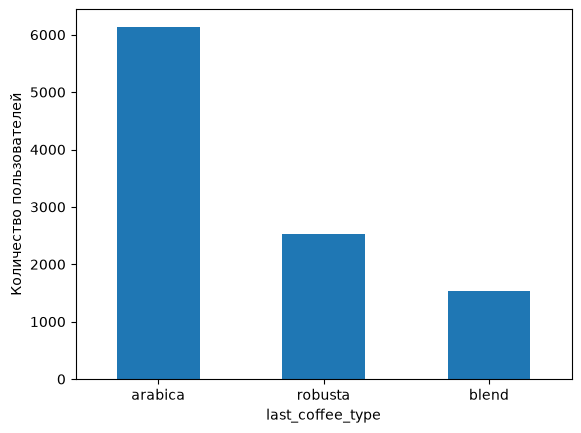

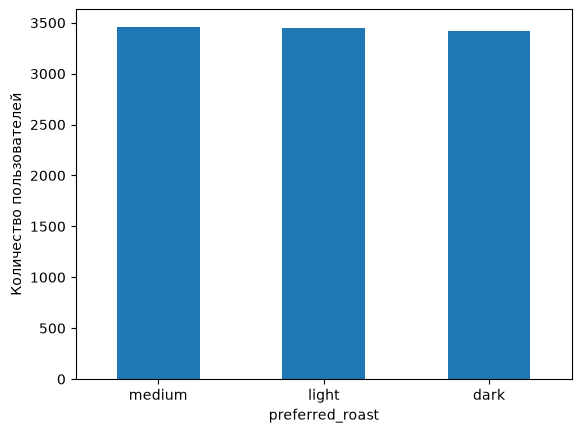

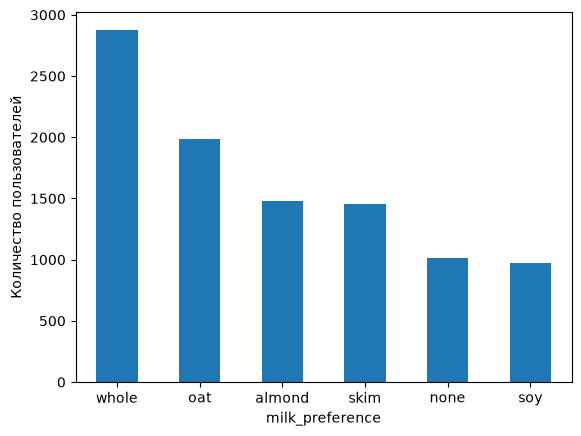

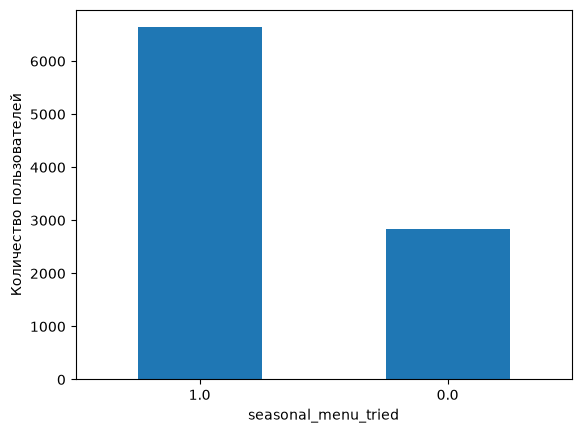

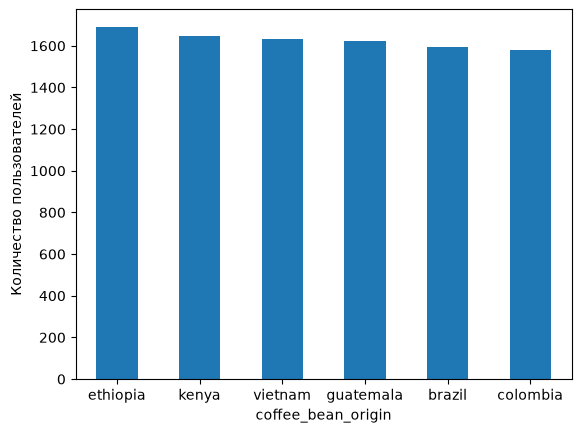

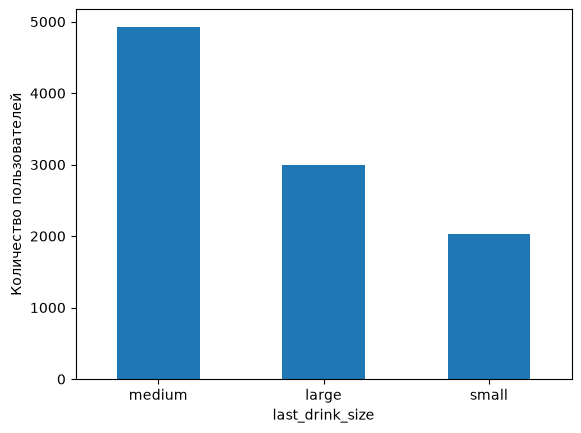

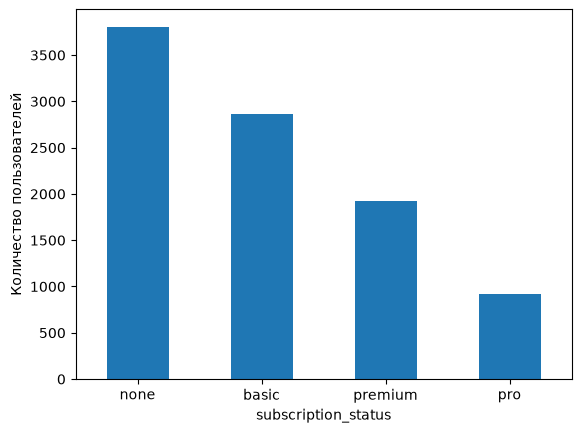

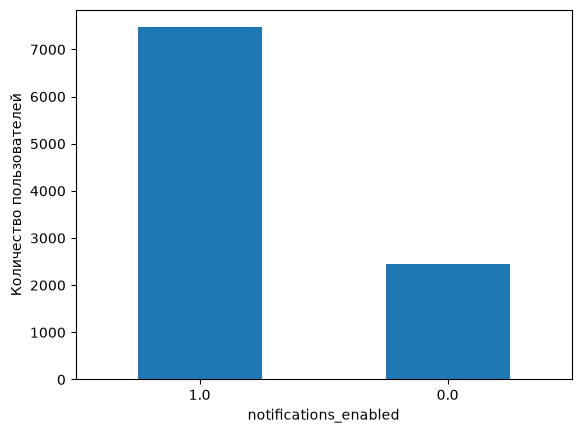

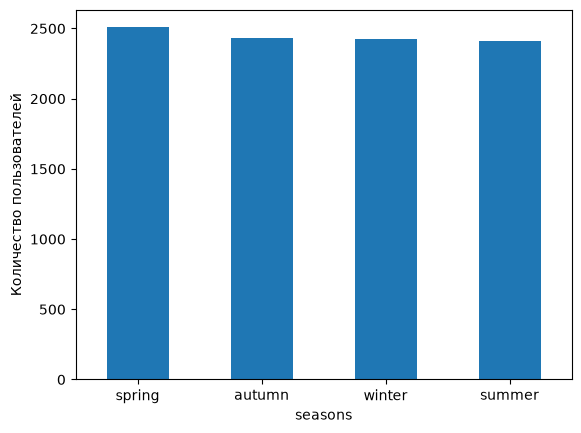

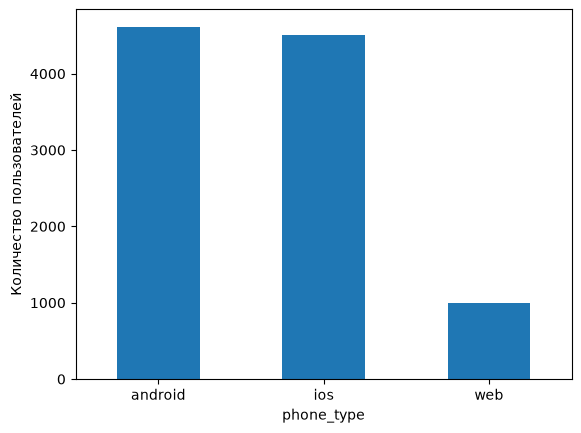

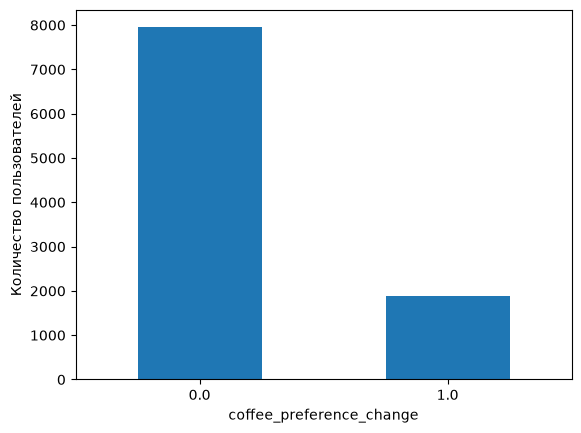

In [ ]:
for cat in cats:
    df[cat].value_counts().plot(
        kind='bar'
        ,rot=0
        ,ylabel='Количество пользователей'
    )
    plt.show()


Из перечисленных категориальных признаков можно выделить следующие:

- 3 признака являются бинарными и не требуют кодировки
- признаки `seasons`, `coffee_bean_origin` и `preferred_roast` имеют близкое к равному распределение и при отсутствии значимой корреляции можно исключить из модели
- оставшиеся 5 признака за исключением geo_location можно закодировать с помощью One-Hot Encoding ввиду небольшого количества уникальных значений в них
- столбец geo_location имеет 100 уникальных значений и будет предпочтительно использовать Target Encoding


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Здесь также согласен.



### 6. Выбросы в данных
Построим ящик с усами для каждого признака, чтоб оценить выбросы в датасете

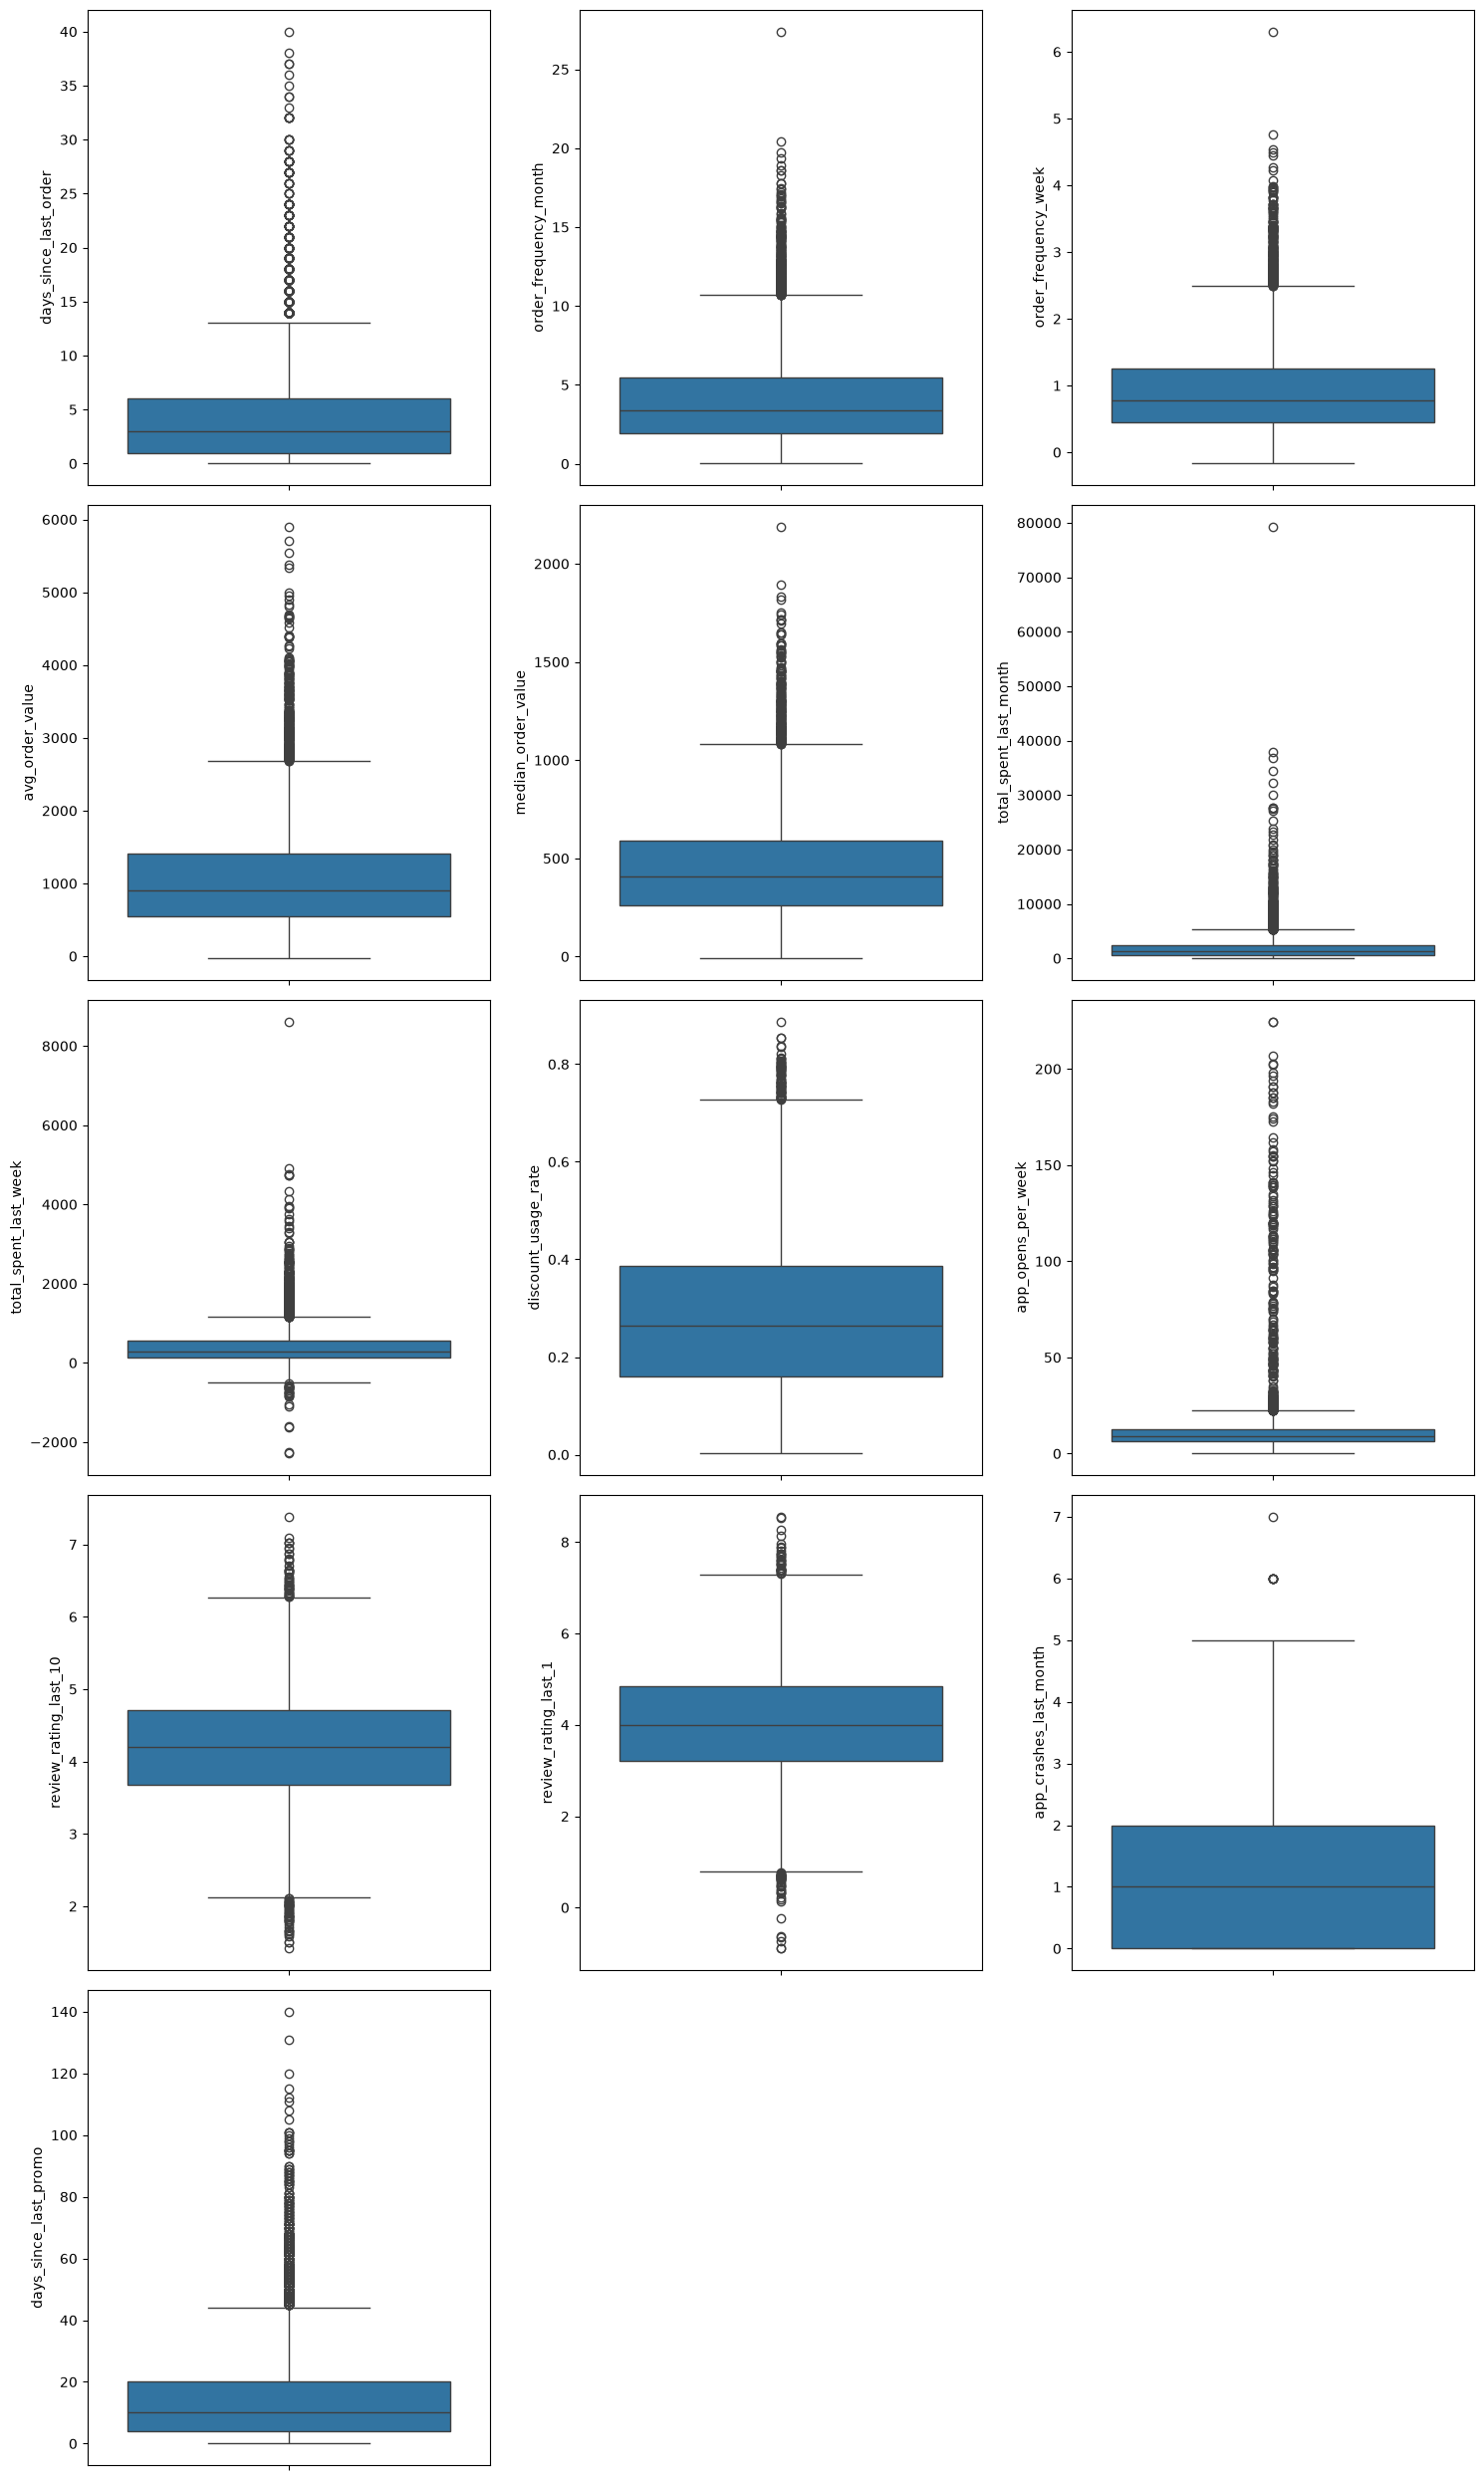

In [ ]:
def boxplot_matrix(data):
    '''Функция для создания матрицы графиков boxplot
    для каждого числового признака с шириной 3
    '''
    iter_col = iter(data.columns.tolist())
    count_v = math.ceil(data.shape[1] / 3)
    fig, ax = plt.subplots(count_v, 3, figsize=(15, 5 * count_v), squeeze=False)
    for i in range(count_v):
        for j in range(3):
            col = next(iter_col, None)
            if col is None:
                ax[i, j].axis('off')
                continue
            sns.boxplot(
                y=data[col],
                ax=ax[i, j]
            )
    plt.tight_layout()
boxplot_matrix(df[nums])   

In [ ]:
#Выведем отдельно максимальное отклонение для каждого столбца
for col in nums:
    max_dev = ((df[col] - df[col].median()).abs().max() / df[col].median()) * 100
    print(f"Макс. отклонение от медианы для столбца {col}: {max_dev:.2f}%")

Макс. отклонение от медианы для столбца days_since_last_order: 1233.33%
Макс. отклонение от медианы для столбца order_frequency_month: 710.07%
Макс. отклонение от медианы для столбца order_frequency_week: 703.05%
Макс. отклонение от медианы для столбца avg_order_value: 556.76%
Макс. отклонение от медианы для столбца median_order_value: 438.58%
Макс. отклонение от медианы для столбца total_spent_last_month: 5997.99%
Макс. отклонение от медианы для столбца total_spent_last_week: 2888.78%
Макс. отклонение от медианы для столбца discount_usage_rate: 235.36%
Макс. отклонение от медианы для столбца app_opens_per_week: 2333.66%
Макс. отклонение от медианы для столбца review_rating_last_10: 75.67%
Макс. отклонение от медианы для столбца review_rating_last_1: 122.48%
Макс. отклонение от медианы для столбца app_crashes_last_month: 600.00%
Макс. отклонение от медианы для столбца days_since_last_promo: 1300.00%


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Насколько полезен для тебя или для любого читателя вот этот вот список с `Макс. отклонение от медианы для столбца `?
    
В контексте того, что выше уже вывели боксплоты, кажется, что такой список бесполезен.
    
***
    
А вот гистограммы стоило бы добавить.
    
Уже по боксплотам можем предполагать, что у наших признаков будет пуассоновское распределение с большим правым хвостом (количество событий в единицу времени при условии, что события достаточно редки).
 
Тогда, возможно, мы бы хотели убедить модель не обращать слишком большого внимания на слишком высокие значения и подтянуть их к центру распределения. В задании нам предлагают сделать это с помощью логарифмирования или взятия корня признака.
    
Логика такая: клиенты, сделавшие 1 заказ и 10 заказов в месяц могут сильно отличаться по вероятности оттока. А вот клиенты, сделавшие 51 и 60 заказов − почти не отличаться, хотя алгебраически отличие будет все в те же 9 чашек. Чтобы линейная модель могла учесть эту нелинейную зависимость мы и сделаем логарифмирование - оно воспроизведет логику, что ближе к нулю изменения будут более существенными, чем в диапазоне подальше.
    
Здесь нужно посмотреть гистограммы и сделать соответствующие выводы на будущее моделирование.


Данные в датасете в большинстве столбцов сильно скошены. Оставлять их в таком виде при использовании LogReg нельзя, при предобработки самые длинные хвосты можно будет обработать через логарифм, остальные через извлечение корня. Так же надо обязательно избавиться предварительно от отрицательных значений. 

In [ ]:
#Списки столбцов требующих обработки
out_log = ['days_since_last_order', 'total_spent_last_month', 'total_spent_last_week', 'app_opens_per_week', 'days_since_last_promo']
out_sqrt = ['order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'discount_usage_rate']

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Можем предположить, что нелинейно будет связана с оттоком переменная с количеством ошибок приложения. Я бы ее возвел в квадрат, чтобы усилить большие значения. По корреляционному анализу увидим, что это сильный предиктор. Хорошо бы его подчеркнуть для модели.

### 7. Корреляция признаков
Построим матрицу корреляции признаков с помощью Phik, чтобы оценить взаимосвязь признаков с целевой переменной, а также корреляцию признаков между собой для контроля мультиколлинеарности.

In [ ]:
correlation_matrix = df.loc[:, df.columns != 'user_id'].phik_matrix(interval_cols=nums)
correlation_matrix.style.background_gradient(cmap='coolwarm', axis=0)

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
days_since_last_order,1.000000,0.000000,0.000000,0.000000,0.012729,0.000000,0.000000,0.000000,0.000000,0.034494,0.023271,0.043539,0.000000,0.008871,0.000000,0.000000,0.026565,0.027785,0.066396,0.000000,0.000000,0.000000,0.020274,0.022482,0.129053,0.000000
order_frequency_month,0.000000,1.000000,0.990083,0.000000,0.099037,0.414983,0.472064,0.000000,0.000000,0.000000,0.009407,0.027064,0.016783,0.000000,0.000000,0.199785,0.000000,0.017989,0.000000,0.025061,0.009243,0.000000,0.000000,0.000000,0.118190,0.079332
order_frequency_week,0.000000,0.990083,1.000000,0.000000,0.096402,0.382369,0.473355,0.016060,0.013189,0.000000,0.000000,0.000000,0.017263,0.000000,0.000000,0.179130,0.002027,0.000000,0.000000,0.000000,0.011682,0.000000,0.000000,0.008724,0.136302,0.080252
avg_order_value,0.000000,0.000000,0.000000,1.000000,0.890398,0.166837,0.285857,0.023184,0.020625,0.000000,0.000000,0.000000,0.013409,0.020059,0.000000,0.000000,0.000000,0.038050,0.000000,0.034559,0.000000,0.063572,0.000000,0.000000,0.128926,0.032515
median_order_value,0.012729,0.099037,0.096402,0.890398,1.000000,0.446017,0.695032,0.032947,0.026183,0.000000,0.018388,0.023362,0.000000,0.005186,0.038636,0.012567,0.028692,0.000000,0.000000,0.000000,0.019665,0.000000,0.022158,0.026813,0.000000,0.000000
total_spent_last_month,0.000000,0.414983,0.382369,0.166837,0.446017,1.000000,0.609608,0.027281,0.016064,0.000000,0.000000,0.000000,0.000000,0.038637,0.019712,0.459848,0.000000,0.000000,0.000000,0.000000,0.026626,0.000000,0.033527,0.025709,0.069082,0.033998
total_spent_last_week,0.000000,0.472064,0.473355,0.285857,0.695032,0.609608,1.000000,0.002044,0.013742,0.000000,0.000000,0.000000,0.029290,0.029070,0.026496,0.094457,0.005031,0.000000,0.000000,0.000000,0.026038,0.000000,0.000000,0.000000,0.048666,0.064183
discount_usage_rate,0.000000,0.000000,0.016060,0.023184,0.032947,0.027281,0.002044,1.000000,0.000000,0.000000,0.038955,0.020923,0.000000,0.000000,0.025947,0.000000,0.011988,0.008239,0.000000,0.000000,0.026710,0.000000,0.000000,0.036829,0.114433,0.028110
last_coffee_type,0.000000,0.000000,0.013189,0.020625,0.026183,0.016064,0.013742,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010053,0.009019,0.039906,0.000000,0.044643,0.005376,0.040072,0.000000,0.000000,0.024801,0.004434
preferred_roast,0.034494,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.021292,0.000000,0.000000,0.031336,0.009243,0.041330,0.004573,0.012704,0.000000,0.000000,0.072438,0.000000,0.078271,0.000000


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Хорошо бы таблицу визуализировать через тепловую карту.

<br/>
<div class="alert alert-info">
Но ведь при использовании стиля и так получается тепловая карта, даже без вызова хитмапа от плота или снс
</div>

У некоторых столбцов можно наблюдать сильную мультиколлинеарность:
- avg_order_value и median_order_value (0.89)
- order_frequency_week и order_frequency_month (0.99)
При предобработке следует убрать по одному столбцу и указанных пар, выбрав тот, что наименьшим образом влияет на целевую переменную

In [ ]:
correlation_matrix.loc[correlation_matrix.index != 'churn'][['churn']].sort_values('churn', ascending=False).style.background_gradient(cmap='coolwarm', axis=0)

,churn
app_crashes_last_month,0.853545
app_opens_per_week,0.126117
subscription_status,0.105164
order_frequency_week,0.080252
order_frequency_month,0.079332
total_spent_last_week,0.064183
geo_location,0.038881
total_spent_last_month,0.033998
review_rating_last_10,0.033943
avg_order_value,0.032515


У 11 столбцов 0 зависимость от целевой переменной, их можно удалить при предобработке.

Единственный столбец с сильной зависимостью - это `app_crashes_last_month`

In [ ]:
columns_to_drop.extend(['coffee_preference_change', 'days_since_last_promo', 'seasons'
                        , 'milk_preference', 'coffee_bean_origin', 'seasonal_menu_tried'
                        ,'last_drink_size', 'notifications_enabled', 'preferred_roast'
                        ,'median_order_value', 'days_since_last_order', 'order_frequency_month'
                        ])

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Околонулевая зависимость еще не говорит, что признак бесполезен. Правильнее будет не исключать признаки, а посмотреть, уберутся ли они регуляризацией (занулятся ли веса), посмотреть на важность признаков для модели, посмотреть на качество модели с признаками и без них, после этого уже делать более взвешенный вывод по лишним.
    
Как правило, если есть теоретическая связь признака с таргетом, удалять его просто по корреляционному анализу не стоит (конечно, кроме случаев очевидно лишних признаков и случаев мультиколлинеарности с полным дублированием одного признака другим).

### 8. Выводы по результатам исследовательского анализа данных

Первичный анализ показал, что датасет пригоден для обучения логистической регрессии, но требует обязательной предобработки: удаления неинформативных и дублирующих признаков, заполнения пропусков, обработки скошенных распределений и перевода целевой переменной в условия сильного дисбаланса классов.

#### 1. Общая структура данных

Датасет содержит **10 450 строк и 27 столбцов**: идентификатор `user_id`, **13 числовых** и **12 категориальных** признаков, а также бинарную целевую переменную `churn`. Одна строка — один пользователь, поэтому дубликатов по объектам нет, а `user_id` не несёт предиктивного смысла и должен быть удалён до обучения (в матрице Phik он дал ложную связь 1.000 со всеми столбцами именно из-за уникальности значений).

#### 2. Целевая переменная

Наблюдается **сильный дисбаланс классов**: 629 ушедших пользователей (**6.02 %**) против 9 821 оставшегося (**93.98 %**), то есть примерно **1 : 15.6**. Следствия:

- метрика `accuracy` непригодна — модель, всегда предсказывающая «не ушёл», даст ~94 % точности при нулевой практической пользе;
- для оценки качества нужны `precision`, `recall`, `f1`, `roc_auc`/`pr_auc`, а качество базовой модели следует сравнивать с этим «наивным» уровнем;

#### 3. Информативность признаков

Расчёт Phik с целевой переменной выявил крайне неравномерную картину:

- **11 столбцов с нулевой связью** (`days_since_last_order`, `median_order_value`, `preferred_roast`, `notifications_enabled`, `last_drink_size`, `seasonal_menu_tried`, `coffee_bean_origin`, `milk_preference`, `seasons`, `days_since_last_promo`, `coffee_preference_change`) можно удалить на предобработке — они не несут линейной информации о оттоке. Ещё три признака (`phone_type`, `last_coffee_type`, `review_rating_last_1`) практически бесполезны и тоже являются кандидатами на удаление.
- **`app_crashes_last_month` выделяется на порядок** (0.854 против 0.126 у следующего признака). Такое значение означает крайне высокую зависимость с целевой переменной.

#### 4. Пропуски

- Столбцов без пропусков всего два — `user_id` и `churn`; в остальных доля пропусков лежит в диапазоне **1.1 % – 9.5 %** (максимум — `seasonal_menu_tried` 9.5 %, `days_since_last_order` и `total_spent_last_week` по 9.0 %).
- Проверка связанности пропусков показала, что **пропуски в разных столбцах практически независимы**: из 944 строк с пропуском в `total_spent_last_week` пропуск в `order_frequency_week` встречается лишь в 41 случае; из 945 строк без `days_since_last_order` пропуск в `order_frequency_month` — в 55; из 896 строк без `app_opens_per_week` пропуск в `order_frequency_week` — в 33. То есть гипотеза «пользователь не проявлял активности — поэтому признаки отсутствуют» не подтверждается, а единого механизма пропусков не видно.
- Пропуски составляют менее 10 % по каждому столбцу, поэтому удаление строк неоправданно. Рационально заполнять их **медианой для числовых** и **модой для категориальных** признаков, причём статистики нужно вычислять **только на обучающей выборке**, чтобы не переносить информацию из теста.

#### 5. Категориальные признаки

- **3 бинарных признака** (`seasonal_menu_tried` — 70.1 % единиц, `notifications_enabled` — 75.3 %, `coffee_preference_change` — 19.3 %) не требуют кодирования. При этом по результатам Phik все три показали нулевую связь с оттоком, то есть их ценность для модели под вопросом.
- **`seasons`, `coffee_bean_origin`, `preferred_roast`** имеют близкое к равномерному распределение и нулевую корреляцию с целевой переменной — их можно исключить из модели без потери качества.
- Оставшиеся признаки с небольшой кардинальностью (`last_coffee_type` — 3 уровня, `milk_preference` — 6, `last_drink_size` — 3, `subscription_status` — 4, `phone_type` — 3) кодируются через **One-Hot Encoding**.
- **`geo_location` содержит 100 уровней** и сильно неравномерен: `geo_1`, `geo_2`, `geo_3` вместе покрывают ≈45 % данных, тогда как остальные 97 уровней насчитывают от 38 до 117 пользователей. One-Hot по такому столбцу добавит ~100 разреженных признаков, поэтому предпочтителен **Target Encoding**.

#### 6. Выбросы и форма распределений

Ящики с усами показали, что **данные в большинстве столбцов сильно скошены**, а «выбросы» представляют собой длинные правые хвосты (крупные траты и высокая частота заказов у отдельных пользователей). Оставлять такие распределения в логистической регрессии нельзя: линейная модель чувствительна к масштабу и хвостам. При предобработке самые длинные хвосты нужно сглаживать логарифмом, остальные — извлечением квадратного корня, а перед этим обязательно **устранить отрицательные значения**, которые присутствуют в 6 числовых столбцах (`order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `review_rating_last_1`) и делают логарифмирование невозможным.

#### 7. Мультиколлинеарность

Корреляционная матрица Phik показала выраженную избыточность признаков:

- `order_frequency_week` ↔ `order_frequency_month` — **0.99**;
- `avg_order_value` ↔ `median_order_value` — **0.89**;

Первая пара фактически дублирует друг друга (недельная и месячная частота заказов — одно и то же поведение в разных окнах). При построении модели из каждой пары следует оставлять **один** признак — тот, у которого выше связь с целевой переменной: например, `order_frequency_week` (0.080) вместо `order_frequency_month` (0.079), и `avg_order_value` (0.033) вместо `median_order_value` (0.000). Второй столбец из пары, помимо устранения мультиколлинеарности, уносит с собой и нулевую информативность, то есть удаляется дважды обоснованно.

#### 8. Что это даёт для этапа 3

1. Удалить `user_id`, 11 признаков с нулевым Phik, а также `phone_type`, `last_coffee_type`, `review_rating_last_1`; из коррелирующих пар оставить по одному признаку.
2. Заполнить пропуски медианой (числовые) и модой (категориальные) внутри пайплайна, обученного только на тренировочной части.
3. Категориальные с малой кардинальностью — One-Hot; `geo_location` — Target Encoding.
4. Числовые признаки — сдвиг/коррекция отрицательных значений, затем логарифм или квадратный корень для сглаживания хвостов, затем масштабирование и нормализация.
5. Учесть дисбаланс классов и оценивать модель по `f1`/`roc_auc`/`pr_auc`, а не по `accuracy`.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Здесь все верно, думаю, можно было бы даже сделать короче. Предполагаем, что читатель видел наше решение и комментарии выше, по второму разу слово в слово повторять все не нужно. Здесь опять же лучше выделять главное, аргументировать наши решения.

<br/>
<div class="alert alert-info">
Просто в паре прошлых работ наоборот просили подробный вывод с обоснованием, что люди часто пропускают шаги и сразу переходят к выводам
</div>

## Этап 3. Предобработка данных

Цель данного этапа — подготовить данные к обучению модели, сохранив их статистические свойства и исключив утечку информации из тестовой выборки. Для этого данные сначала разделяются в пропорции 80/20: 20% откладываются для финального теста, а оставшиеся 80% используются для обучения и кросс-валидации. Все параметры предобработки — статистики пропусков, категориальные уровни, границы выбросов — вычисляются **только на обучающей части**.

В рамках предобработки создаются три пайплайна:

- **Пайплайн обработки категориальных признаков** — кодирование категорий на основе данных, доступных только в обучающей выборке.
- **Пайплайн обработки числовых признаков** — масштабирование и нормализация числовых значений для приведения их к сопоставимому виду.
- **Единый препроцессор первичной обработка данных** - обьединяет в себе результаты двух других пайплайнов

Такая организация позволяет воспроизводимо применять преобразования к любым новым данным и гарантирует, что модель не «подсматривает» информацию из тестовой выборки.

### 1. Разделение датасета на выборки

In [ ]:
X = df.drop(columns=['churn'])
y = df['churn']
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True, stratify=y
)

### 2. Пайплайн обработки категориальных данных
Категориальные признаки требуют двух разных стратегий: для признаков с небольшим количеством уникальных значений достаточно One-Hot, для `geo_location` со 100 категориями — целевая кодировка, которая заменяет категорию средним значением целевой переменной.

In [ ]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
targ_encode_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('TarEnc', TargetEncoder())
])

### 3. Пайплайн обработки числовых данных
Числовые признаки содержат пропуски и имеют разные масштабы, поэтому им нужны заполнение и стандартизация — без неё регуляризация в логистической регрессии наказывает признаки неравномерно.

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

### 4. Единый препроцессор обработки данных
`ColumnTransformer` объединяет две ветки обработки в один объект, который затем целиком включается в пайплайн модели. Это гарантирует, что любые преобразования применяются одинаково.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, nums),
        ('cat', cat_pipeline, cats),
        ('special', targ_encode_pipeline, ['geo_location'])
    ]
)

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 

## Этап 4. Обучение модели

Сначала обучается базовая версия модели — логистическая регрессия на исходном наборе признаков с минимальными настройками. Она задаёт точку отсчёта, относительно которой измеряется вклад новых признаков и подбора гиперпараметров.

In [ ]:
baseline_pipe = Pipeline([
    ('prep', preprocessor)
    ,('model', LogisticRegression(random_state=RANDOM_STATE))
])
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cross_val_baseline = cross_validate(baseline_pipe, X_train_val, y_train_val, cv=kfold, scoring=SCORING_BASELINE, n_jobs=-1)

In [ ]:
enhanced_means = {
    "f1": np.mean(cross_val_baseline['test_f1']),
    "pr_auc": np.mean(cross_val_baseline['test_average_precision']),
    'precision': np.mean(cross_val_baseline['test_precision']),
    'recall': np.mean(cross_val_baseline['test_recall'])
}
print("Результаты модели (средние значения):")
print("-" * 50)
print(f"F1: {enhanced_means['f1']:.3f}")
print(f"PR-AUC:   {enhanced_means['pr_auc']:.3f}")
print(f"Precision:   {enhanced_means['precision']:.3f}")
print(f"Recall:   {enhanced_means['recall']:.3f}")

Результаты модели (средние значения):
--------------------------------------------------
F1: 0.547
PR-AUC:   0.667
Precision:   0.762
Recall:   0.433


**Выводы**
- Базовая модель: `preprocessor` + `LogisticRegression(random_state=42)`, 52 признака, кросс-валидация 5 фолдов.
- Метрики: F1 = 0.5473 ± 0.0533, PR-AUC = 0.6670 ± 0.0486.
- Recall (0.4335) заметно ниже Precision (0.7617) при пороге 0.5 — модель осторожна. Это уже указывает на необходимость отдельного подбора порога классификации.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Все верно

## Этап 5. Создание новых признаков

На текущем этапе мы переходим от базового пайплайна к осмысленной работе с признаками. Цель — не просто обучить модель, а понять, какие признаки действительно влияют на её решения, и использовать это понимание для улучшения качества.

### 1. Добавление новых признаков

Опираясь на наработки, полученные в ходе исследовательского анализа данных (EDA), и на логику решаемой задачи, необходимо сконструировать новые признаки, которые могут улучшить качество модели. В качестве отправной точки можно использовать монотонные преобразования, уже зарекомендовавшие себя на скошенных распределениях:

- **Извлечение квадратного корня** — поможет сгладить большие значения и уменьшить влияние правого хвоста распределения.
- **Возведение в квадрат** — напротив, усилит влияние больших значений и может помочь модели уловить нелинейные эффекты.

### 2. Обновление пайплайна и кросс-валидация

После добавления признаков нужно обновить пайплайн так, чтобы новые преобразования применялись корректно — внутри `Pipeline`, без утечки данных между фолдами.

In [ ]:
#Переменная с столбцами на удаление
columns_to_drop
# признаки, создаваемые в create_features
engineered_features = ['crash_opens']
#Создание переменных содержащих списки категориальных и числовых признаков с вычетом удаляемых столбцов
nums_pred = [x for x in nums if x not in set(columns_to_drop)] + engineered_features
cats_pred = [x for x in cats if x not in set(columns_to_drop)]
out_log_pred = [x for x in out_log if x not in set(columns_to_drop)]
out_sqrt_pred = [x for x in out_sqrt if x not in set(columns_to_drop)]

In [ ]:
def create_features(X):
    '''Служит для обработки выбросов, удаления лишних столбцов и усиления признаков
    '''
    X_enhanced = X.copy()
    
    #Создадим новый признак на основе двух признаков с самой сильной связью с целевой переменной
    X_enhanced['crash_opens'] = X['app_crashes_last_month'] * X['app_opens_per_week']
    
    #Обработка наиболее сильных выбросов с помощью логармифа
    for out in out_log_pred:
        X_enhanced[out] = np.log1p(np.clip(X[out], a_min=0, a_max=None))
    
    #Обработка наиболее сильных выбросов с помощью корня
    for out in out_sqrt_pred:
        X_enhanced[out] = np.sqrt(np.clip(X[out], a_min=0, a_max=None))
        
    #Возведение в квадрат наиболее сильного признака
    X_enhanced['app_crashes_last_month'] = X['app_crashes_last_month'] ** 2
    
    #Убираем отрицательные значения у оставшегося столбца
    X_enhanced['review_rating_last_1'] = np.clip(X['review_rating_last_1'], a_min=0, a_max=None)
        
    #Удаление лишних столбцов
    X_enhanced.drop(columns=columns_to_drop, inplace=True)
    
    return X_enhanced

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отличная работа. Практикум рекомендует аргументацию выносить в текстовый комментарий. В остальном все супер логично. Посмотрим, как все сработает.

In [ ]:
fin_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, nums_pred),
        ('cat', cat_pipeline, cats_pred),
        ('special', targ_encode_pipeline, ['geo_location'])
    ]
)
fin_pipeline = Pipeline([
    ('create_features', FunctionTransformer(create_features)),
    ('prep', fin_preprocessor),
    ('LogReg', LogisticRegression(random_state=RANDOM_STATE))
])

## Этап 6. Эксперименты с гиперпараметрами

Эксперименты ставятся над двумя ключевыми гиперпараметрами логистической регрессии: `C` (обратная сила регуляции) и `class_weight` (компенсация дисбаланса классов). Так же производится подбор оптимального порога.

### 1. Определение пространства гиперпараметров

Подготовка словаря с оптимальным набором гиперпараметров

### 2. Систематический перебор с кросс-валидацией

Далее — систематический перебор гиперпараметров для `LogisticRegression`. Для каждой конфигурации проводится кросс-валидация по единой схеме (например, `StratifiedKFold` с фиксированным `random_state`), чтобы результаты были сопоставимы между собой. Все преобразования признаков должны выполняться внутри `Pipeline`, чтобы не допустить утечки данных между фолдами.

### 3. Таблица результатов

Результаты перебора оформляются в виде таблицы: конфигурация гиперпараметров и соответствующая метрика качества (среднее по фолдам и, желательно, стандартное отклонение).


### 1. Создание словаря гиперпараметров

In [ ]:
param_grid = {
    'LogReg__C': [0.01, 0.1, 1, 10, 100],
    'LogReg__class_weight': [None, 'balanced'],
}

### 2. Перебор гиперпараметров с помощью GridSearchCV

In [ ]:
grid = GridSearchCV(
    fin_pipeline,
    param_grid,
    scoring=SCORING_GRID_SEARCH,
    cv=kfold,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train_val, y_train_val)
print()

### 3. Вывод результатов отбора с сортировкой по лучшей модели 

In [ ]:
df_results = pd.DataFrame(grid.cv_results_)
df_results.sort_values('rank_test_score').head(8)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_LogReg__C,param_LogReg__class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.059849,0.022039,0.018044,0.003718,0.10,NaN,"{'LogReg__C': 0.1, 'LogReg__class_weight': None}",0.672822,0.662472,0.706692,0.791168,0.714439,0.709519,0.045297,1
4,0.054518,0.006489,0.016293,0.001097,1.00,NaN,"{'LogReg__C': 1, 'LogReg__class_weight': None}",0.666931,0.663260,0.707786,0.791576,0.710168,0.707944,0.046213,2
3,0.068309,0.010733,0.018409,0.004133,0.10,balanced,"{'LogReg__C': 0.1, 'LogReg__class_weight': 'ba...",0.668520,0.661455,0.695102,0.778892,0.719400,0.704674,0.042407,3
6,0.044954,0.000744,0.017332,0.001456,10.00,NaN,"{'LogReg__C': 10, 'LogReg__class_weight': None}",0.656366,0.655136,0.703738,0.789727,0.708452,0.702684,0.049025,4
5,0.049176,0.001461,0.016084,0.001480,1.00,balanced,"{'LogReg__C': 1, 'LogReg__class_weight': 'bala...",0.659096,0.657362,0.694255,0.777668,0.719645,0.701605,0.044563,5
0,0.078525,0.005657,0.015740,0.003217,0.01,NaN,"{'LogReg__C': 0.01, 'LogReg__class_weight': None}",0.655662,0.648402,0.686288,0.774092,0.715217,0.695932,0.045727,6
8,0.048057,0.004464,0.016936,0.003091,100.00,NaN,"{'LogReg__C': 100, 'LogReg__class_weight': None}",0.642703,0.650657,0.696141,0.782404,0.702237,0.694829,0.049788,7
7,0.052636,0.003571,0.017854,0.002691,10.00,balanced,"{'LogReg__C': 10, 'LogReg__class_weight': 'bal...",0.643461,0.643717,0.686227,0.771930,0.710859,0.691239,0.047879,8



<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>

Думаю, для нашей задачи и метрики идеальный порог будет либо 0.5, либо очень близко к нему. Подбирать порог под метрику, которая замеряет прощадь под кривой будет ошибочно, так как метрика считается по вероятностям классов, значит не зависит от порога. 
    
Оптимизироваться под recall или precision тажке не стоит, так как при качестве, которое не слишком близко к идеальному, моделям будет выгоднее выродиться в константные (логично, при постоянном предсказании только нулевого класса precision будет максимальным, но такая модель ничего не объясняет и бесполезна для бизнеса). 


## Этап 7. Подготовка финальной модели

Подготовка и тестирование лучшей модели на тестовой выборке

In [ ]:
best_model = grid.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

In [ ]:
print("Результаты модели:")
print("-" * 50)
print(f"F1: {round(f1_score(y_test, y_pred), 3)}")
print(f"PR-AUC:   {round(average_precision_score(y_test, y_pred_proba), 3)}")
print(f"Precision:   {round(precision_score(y_test, y_pred), 3)}")
print(f"Recall:   {round(recall_score(y_test, y_pred), 3)}")

Результаты модели:
--------------------------------------------------
F1: 0.66
PR-AUC:   0.751
Precision:   0.831
Recall:   0.548


## Выводы

1. Итоговая конфигурация: `create_features` → `fin_preprocessor` → `LogisticRegression(C=0.1, class_weight=None)`. На вход модели после кодирования подаётся **21 признак**, среди них новый `crash_opens` и квадрат числа сбоев. Сила регуляризации выбрана по кросс-валидации и оказалась на порядок слабее значения по умолчанию: самый сильный признак не нужно сжимать, поэтому модель выигрывает от более свободных коэффициентов.
2. Кросс-валидация по PR-AUC даёт **0.7095** (округлённо 0.710) при разбросе по фолдам ±0.045. Разрыв с базовой моделью этапа 4 (0.6670) составляет **+0.043**, то есть работа с признаками дала ощутимый прирост, а не шум.
3. Оптимум по силе регуляризации выражен слабо: `C=1` даёт 0.7079, `C=0.1` с `class_weight='balanced'` — 0.7047, `C=100` с `balanced` — 0.6853. Разница между первыми тремя конфигурациями лежит внутри разброса по фолдам, поэтому дальнейшее уточнение `C` смысла не имеет.
4. Основной вклад в качество дали признаки, а не модель.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
`Порог 0.285 — компромисс, а не оптимум вообще` - абсолютно согласен. Давай тогда порог пока не трогать, у нас нет достаточных вводных для подбора порога. Наша задача − эффективный алгоритм для разделения под 0.5 порог.

## Этап 8. Отчёт о проделанной работе

### 1. Задача и данные

Цель работы — построить модель логистической регрессии, прогнозирующую отток клиента кофейной сети, и объяснить факторы оттока. Использован датасет `coffee_churn_dataset.csv`: 10 450 записей, 27 столбцов — идентификатор `user_id`, 13 числовых и 12 категориальных признаков и бинарная целевая переменная `churn`. Целевой класс сильно разбалансирован: 629 ушедших (6.02 %) против 9 821 оставшегося (93.98 %), то есть 1 : 15.6. Данные разделены на обучающую и тестовую выборки в пропорции 80/20 со стратификацией по целевой переменной

### 2. Что показал исследовательский анализ

Главный результат EDA — признак `app_crashes_last_month` практически детерминированно связан с оттоком. Его Phik с целевой переменной равен 0.854 против 0.126 у следующего по силе признака. Остальные связи слабые: `app_opens_per_week` 0.126, `subscription_status` 0.105, `order_frequency_week` 0.080, `geo_location` 0.039, у 14 столбцов значение ниже 0.02. 

### 3. Предобработка и конструирование признаков

Из исходных 27 столбцов удалены `user_id`, 11 признаков с нулевым Phik и по одному признаку из каждой коррелирующей пары. Формируется единый препроцессор: медианное заполнение и стандартизация для числовых признаков, мода и One-Hot для категориальных, Target Encoding для `geo_location`. Поверх препроцессора стоит `FunctionTransformer` с функцией `create_features`, которая внутри пайплайна: создаёт произведение числа сбоев на активность в приложении (`crash_opens`), сглаживает длинные хвосты логарифмом (`total_spent_last_month`, `total_spent_last_week`, `app_opens_per_week`) и квадратным корнем (`order_frequency_week`, `avg_order_value`, `discount_usage_rate`), устраняет отрицательные значения в `review_rating_last_1` и заменяет число сбоев его квадратом для усиления нелинейного эффекта. Все преобразования выполняются внутри `Pipeline`, поэтому статистики обучаются только на тренировочной части каждого фолда — утечки данных нет. На вход модели после кодирования подаётся 21 признак.

### 4. Модель и подбор гиперпараметров

Выбрана логистическая регрессия как интерпретируемая базовая модель бинарной классификации. Перебор вёлся по 10 конфигурациям (`C` из набора 0.01, 0.1, 1, 10, 100 × `class_weight` из `None` и `balanced`) с `GridSearchCV`, схемой `StratifiedKFold` на 5 фолдов и метрикой `average_precision` (PR-AUC), которая корректна при сильном дисбалансе классов. Лучшей стала конфигурация `C = 0.1`, `class_weight = None` со средним PR-AUC 0.7095 ± 0.0453; второе место у `C = 1` (0.7079), третье у `C = 0.1` с `balanced` (0.7047).



<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Как будто бы тоже лучше чуть компактнее все написать, выделив главное. Подробные перечисления не нужны любому потенциальному читателю, которого здесь можем представить в виде читателя нашего проекта: коллегу, заказчика, руководителя, будущего работодателя, которому покажем работу в портфолио, ревьюера. Тогда зачем такие перечисления?

## Этап 9. Сохранение модели для продакшена

Чтобы модель можно было использовать вне ноутбука, сохраняется не только сама логистическая регрессия, но и весь пайплайн: обработка выбросов (`create_features`), импутеры, масштабирование, One-Hot- и TargetEncoder.

In [ ]:
artifact = {
    "model": best_model,
    "features": list(X_train_val.columns),
    "classes": best_model.classes_.tolist(),
}

joblib.dump(artifact, 'model_artifact.joblib')

NameError: name 'THRESHOLD' is not defined

In [ ]:
art = joblib.load('model_artifact.joblib')
lmodel_model = art['model']
lmodel_features  = art["features"]

y_proba_load = lmodel_model.predict_proba(X_test)[:, 1]
y_pred_load = lmodel_model.predict(X_test)

print(f"F1: {round(f1_score(y_test, y_pred_load), 3)}")
print(f"PR-AUC:   {round(average_precision_score(y_test, y_proba_load), 3)}")


F1: 0.66
PR-AUC:   0.751



<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Здесь нас просят разместить модель в интернете, например, на гитхаб + нас просят также добавить документ с версиями: requirements.txt
    
Этот документ мы можем сформировать автоматически через `pip freeze > requirements.txt`




<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект! Мне было интересно следить за ходом мыслей и твоими решениями. Видны основательная работа и интерес к проекту. Есть несколько важных моментов, которые необходимо улучшить. Их ты найдешь в разноцветных комментариях.
    
**Отмечу положительные моменты проекта🚀**
    
* Хорошая схема проекта.
* Отличные решения в коде, все оптимально, прозрачно, понятно.
* Есть пояснения и аргументация решений.
    
**На что стоит обратить внимание🤔**
    
* Важно добавить гистограммы, изучить распределения, аргументировать создание новых признаков.
* Желательно визуализировать корреляционный анализ через тепловую карту - сделать матрицу корреляции удобной.
* Уточнимся по пороговому значению. 
* Эти и остальные замечания я также написал по ходу проекта.
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>
      